In [1]:
import os
import kagglehub
import shutil
import pandas as pd


path = kagglehub.competition_download('digit-recognizer')

print("Fichiers téléchargés dans :", path)
# Dossier de destination
dest = "data"
#os.makedirs(dest, exist_ok=True)

# Copier tous les fichiers du dossier téléchargé vers /data
for fichier in os.listdir(path):
    src_file = os.path.join(path, fichier)
    dst_file = os.path.join(dest, fichier)
    shutil.copy2(src_file, dst_file)

print("Fichiers copiés dans :", dest)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fichiers téléchargés dans : /home/onyxia/.cache/kagglehub/competitions/digit-recognizer
Fichiers copiés dans : data


In [51]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle

In [87]:
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')

In [ ]:
X_train=df_train.drop(columns=['label'])
X_test=df_test
y_train=df_train['label']

X_train,y_train=shuffle(X_train,y_train) #We shuffle because keras will not do it alone

In [ ]:
def build_model(meta, hidden_units=64):
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]
    model = keras.Sequential([
        keras.Input(shape=(n_features_in,)), #shape of what we put in 
        layers.Reshape((28,28,1)), #We 'transform' it into a picture
        layers.RandomRotation(0.05), #Rotation of about 18 degree
        layers.RandomTranslation(0.1,0.1), #Translation
        layers.RandomZoom(0.1), #Zoom (about +/- 10%)
        layers.Conv2D(32, kernel_size=3,padding="same"), #1st layer of Convolution, to extract spatial structure
        layers.BatchNormalization(),
        layers.Activation("relu"), #Max activation
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3,padding="same"),       
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3,padding="same"),       
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dropout(0.1),
        layers.Dense(hidden_units, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer='adam', #common one, with default learning rate
        loss="sparse_categorical_crossentropy", #good for multiple labels
        metrics=["accuracy"], #we want to optimize accuracy
    )
    return model


clf = KerasClassifier(
    model=build_model,
    hidden_units=128,
    epochs=100, #we can put a big epochs considering that we have an early stopping
    batch_size=64,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)], #important to keep the best_weights at the end, and to monitor val_loss instead of loss
    verbose=0,
)


pipeline = Pipeline([
    ("scaler", MinMaxScaler()), #pipeline that starts by scaling
    ("model", clf),
])

pipeline.fit(X_train, y_train) #fit of our pipeline on train data
preds = pipeline.predict(X_test) #We apply it on our unlabeled data

In [ ]:
clf_fitted=pipeline.named_steps['model'] #to be able to extract history

hist=clf_fitted.history_ #what happened during the fitting
print(hist.keys()) #what metric can we monitor

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [92]:
print(hist['val_accuracy'])
print(len(hist['loss']))

[0.9765475988388062, 0.8941666483879089, 0.981071412563324, 0.9857142567634583, 0.9645237922668457, 0.9842857122421265, 0.9778571724891663, 0.9709523916244507, 0.9845238327980042, 0.9814285635948181, 0.9878571629524231, 0.9888095259666443, 0.987500011920929, 0.9861904978752136, 0.9828571677207947, 0.9928571581840515, 0.9861904978752136, 0.9895238280296326, 0.989047646522522, 0.9889285564422607, 0.9903571605682373, 0.9891666769981384, 0.9916666746139526, 0.9930952191352844]
24


Text(0, 0.5, 'sparse_categorical_crossentropy')

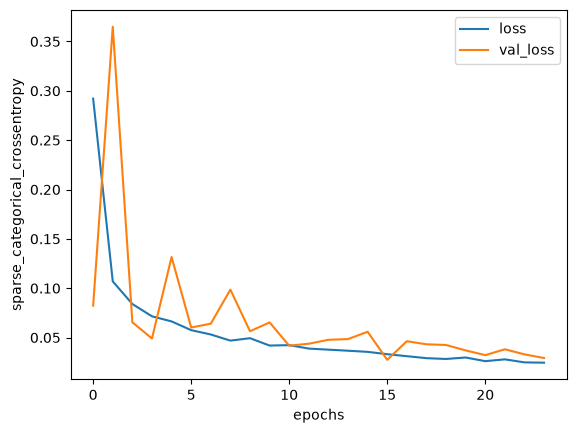

In [ ]:
plt.plot(hist['loss'],label='loss')
plt.plot(hist['val_loss'],label='val_loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('sparse_categorical_crossentropy') #our metric

#This plot allow to see how val_loss evolves with respect to loss, and thus, to know if it overfit, underfit, or plato

In [ ]:
print(round(min(hist["val_loss"]), 4))
print(round(max(hist["val_accuracy"]), 4)) #Just to have an idea wether after changes our model improved
#But we need to be aware of the noise

0.0274
0.9931


In [95]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(preds) + 1),   # ou range(len(preds)) selon le format attendu
    "Label": preds
})
submission.to_csv('soumission_CNN_Early.csv',index=False)